policy_bind_date : False
policy_state : False
policy_csl : False
insured_sex : False
insured_education_level : False
insured_occupation : False
insured_hobbies : False
insured_relationship : False
incident_date : False
incident_type : False
collision_type : True
incident_severity : False
authorities_contacted : False
incident_state : False
incident_city : False
incident_location : False
property_damage : True
police_report_available : True
auto_make : False
auto_model : False
fraud_reported : False
incident_type
incident_type
Multi-vehicle Collision     0.272076
Parked Car                  0.095238
Single Vehicle Collision    0.290323
Vehicle Theft               0.085106
Name: fraud_reported, dtype: float64



C:\Users\User\AppData\Local\Temp\ipykernel_16552\3230817240.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


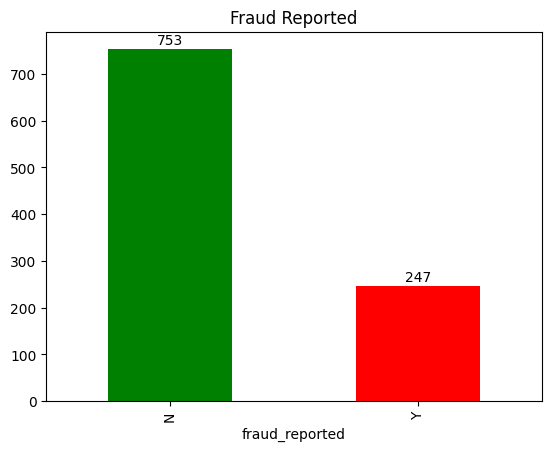

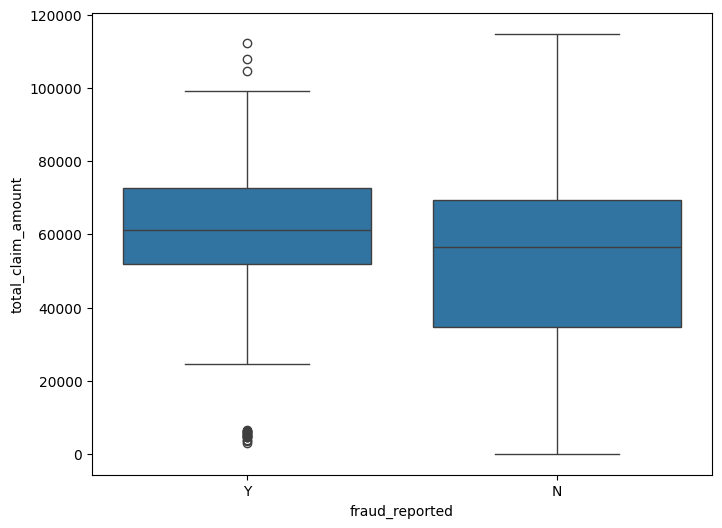

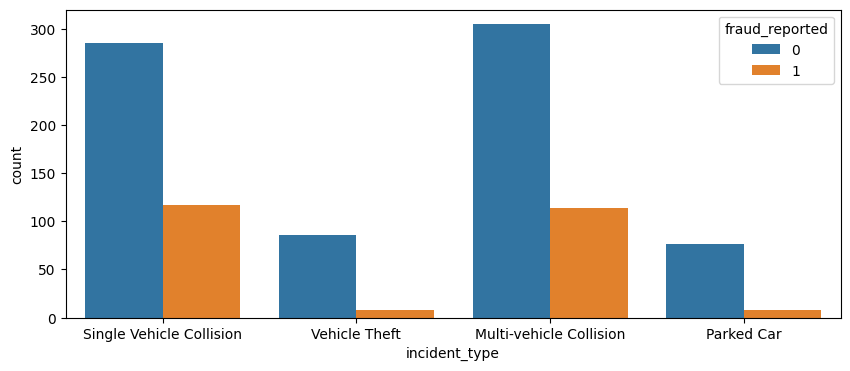

incident_severity
incident_severity
Major Damage      0.605072
Minor Damage      0.107345
Total Loss        0.128571
Trivial Damage    0.066667
Name: fraud_reported, dtype: float64



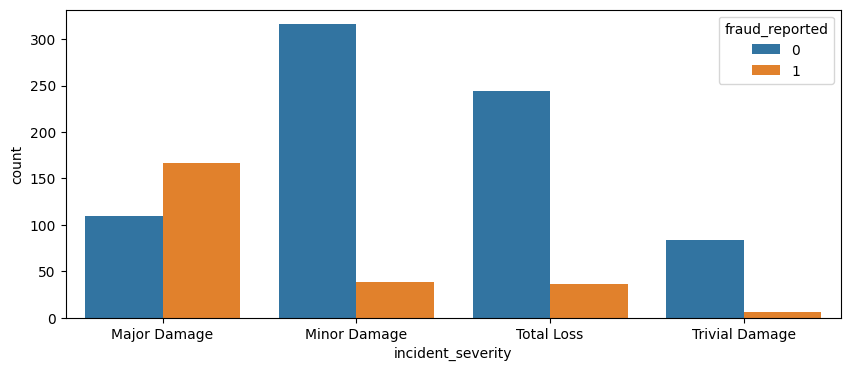

collision_type
collision_type
Front Collision    0.275591
Rear Collision     0.311644
Side Collision     0.253623
Name: fraud_reported, dtype: float64



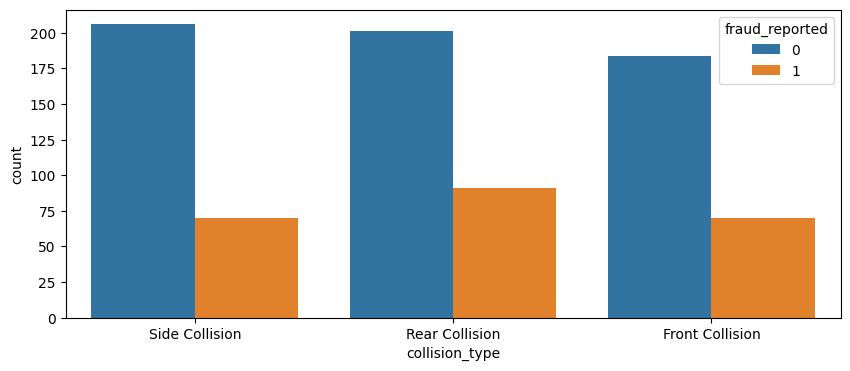

property_damage
property_damage
NO     0.195266
YES    0.258278
Name: fraud_reported, dtype: float64



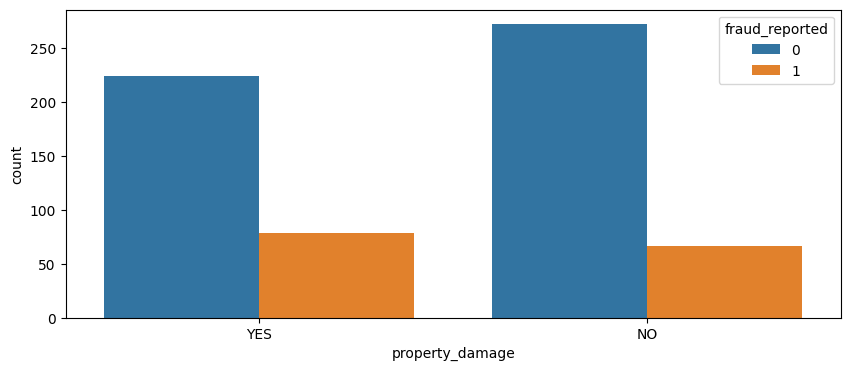

police_report_available
police_report_available
NO     0.250729
YES    0.229299
Name: fraud_reported, dtype: float64



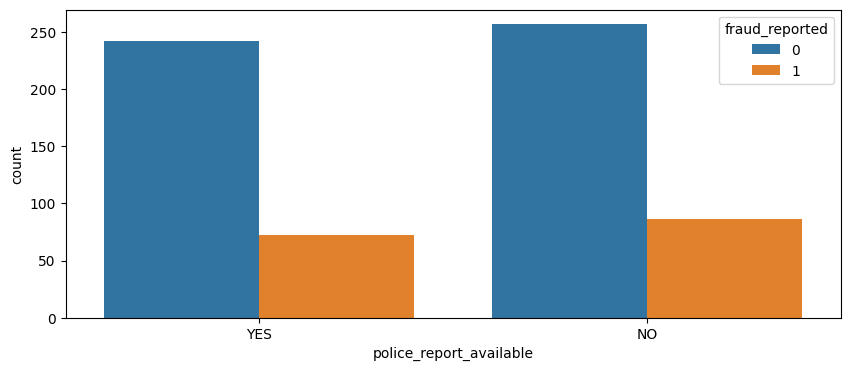

authorities_contacted
authorities_contacted
Ambulance    0.290816
Fire         0.269058
Other        0.318182
Police       0.208904
Name: fraud_reported, dtype: float64



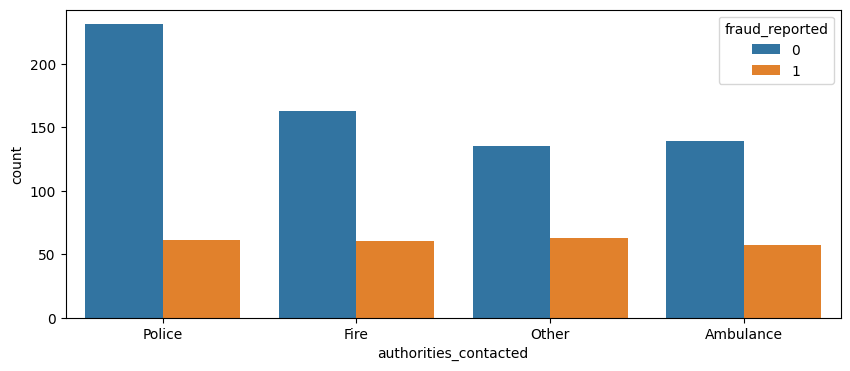

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('insurance_claims.csv')



for col in df.select_dtypes(include='object').columns:
    print(col, ':', '?' in df[col].values)

df[['property_damage', 'police_report_available', 'collision_type']] = df[['property_damage', 'police_report_available', 'collision_type']].replace('?', np.nan)

df['fraud_reported'].value_counts().sort_index().plot(kind='bar', color=['green', 'red'])
plt.title('Fraud Reported')

for i, value in enumerate(df['fraud_reported'].value_counts().sort_index()):
    plt.text(i, value + 10, str(value), ha='center')

plt.figure(figsize=(8, 6))
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df)


df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

df.select_dtypes(include='number').corr()['fraud_reported'].sort_values()


cat_cols = ['incident_type', 'incident_severity', 'collision_type', 
            'property_damage', 'police_report_available', 'authorities_contacted']

for col in cat_cols:
    print(col)
    print(df.groupby(col)['fraud_reported'].mean())
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue='fraud_reported')
    plt.show()



Kategorik sinyaller:

incident_severity → Major Damage %60 fraud ⚡
incident_type → Single Vehicle Collision %29
property_damage → YES daha yüksek
police_report_available → neredeyse fark yok

FE fikirleri çıktı:

vehicle_age = incident_year - auto_year
injury_claim / total_claim_amount oranı
is_single_vehicle binary flag
Isolation Forest anomaly score